# Alibaba Stock Data — Exploratory Data Analysis (EDA)

**Dataset:** `Ali_Baba_Stock_Data.csv`  
**Objective:** Perform a structured EDA on Alibaba's historical stock data to uncover pricing patterns, 
volatility trends, and relationships between key financial indicators.

---
### Notebook Structure
| Section | Title | Category |
|---------|-------|----------|
| 1 | Library Imports & Dataset Overview | Setup |
| 2 | Data Cleaning & Missing Value Treatment | Data Preprocessing — Step 1 |
| 3 | Encoding Categorical Variables | Data Preprocessing — Step 2 |
| 4 | Feature Scaling & Feature Engineering | Data Preprocessing — Step 3 |
| 5 | EDA — Numerical Feature Analysis | Exploratory Data Analysis Part 1 |
| 6 | EDA — Categorical Feature Analysis | Exploratory Data Analysis Part 2 |
| 7 | Correlation Analysis & Heatmap | Exploratory Data Analysis Part 3 |
| 8 | Key Findings, Insights & Limitations | Synthesizing EDA Results |


---
## Section 1: Library Imports & Dataset Overview

We begin by importing the necessary Python libraries for data manipulation, numerical computation, 
and visualisation. We then load the dataset and inspect its basic structure — shape, column names, 
data types, and a preview of the first few rows.

**Libraries Used:**
- `pandas` — tabular data handling
- `numpy` — numerical operations
- `matplotlib` — base plotting library
- `seaborn` — statistical visualisation built on matplotlib


In [1]:
# ── Import core libraries ──────────────────────────────────────────────
import pandas as pd          # Data manipulation and analysis
import numpy as np            # Numerical computations
import matplotlib.pyplot as plt  # Plotting
import seaborn as sns         # Statistical visualisation

# Set matplotlib style to default (clean white background)
plt.style.use('default')

print('Libraries loaded successfully.')


Libraries loaded successfully.


### 1.1 Load the Dataset

We load the CSV file and print the shape, column names, a data-type summary (`info()`), 
and the first five rows (`head()`) to get an initial understanding of the data.


In [2]:
# ── Load dataset ───────────────────────────────────────────────────────
df = pd.read_csv("Ali_Baba_Stock_Data.csv")

print("Shape (rows, cols):", df.shape)
print("\nColumn Names:\n", df.columns.tolist())
print("\nSample Data (first 5 rows):")
display(df.head())

# Detailed type and non-null information
print("\nDataset Info:")
df.info()


Shape (rows, cols): (2617, 7)

Column Names:
 ['Date', 'Adj Close', 'Close', 'High', 'Low', 'Open', 'Volume']

Sample Data (first 5 rows):


,Date,Adj Close,Close,High,Low,Open,Volume
0,2014-09-19,90.673950,93.889999,99.699997,89.949997,92.699997,271879400
1,2014-09-22,86.810966,89.889999,92.949997,89.500000,92.699997,66657800
2,2014-09-23,84.184128,87.169998,90.480003,86.620003,88.940002,39009800
3,2014-09-24,87.467667,90.570000,90.570000,87.220001,88.470001,32088000
4,2014-09-25,85.874191,88.919998,91.500000,88.500000,91.089996,28598000



Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2617 entries, 0 to 2616
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Date       2617 non-null   object 
 1   Adj Close  2617 non-null   float64
 2   Close      2617 non-null   float64
 3   High       2617 non-null   float64
 4   Low        2617 non-null   float64
 5   Open       2617 non-null   float64
 6   Volume     2617 non-null   int64  
dtypes: float64(5), int64(1), object(1)
memory usage: 143.2+ KB


---
## Section 2: Data Cleaning & Missing Value Treatment
*(Data Preprocessing — Step 1)*

Data cleaning is the first and most critical preprocessing step. Raw datasets often contain:
- Invalid or unparseable date entries
- Duplicate records
- Extra whitespace in column names
- Non-numeric values in numeric columns
- Missing (NaN) values

In this section we address all of these issues systematically before any analysis begins.


### 2.1 Date Parsing, Sorting & Deduplication

Stock data is **time-series data**, so correct date handling is essential:
1. Convert the `Date` column to a proper `datetime` type.
2. Drop rows where the date could not be parsed (coerced to `NaT`).
3. Sort chronologically and set `Date` as the index.
4. Remove duplicate index entries to prevent double-counting.
5. Strip whitespace from column names to avoid key-error bugs.
6. Coerce OHLCV columns to numeric (in case any text crept in).


In [3]:
# ── Step 1: Parse dates and handle invalid entries ─────────────────────
df['Date'] = pd.to_datetime(df['Date'], errors='coerce')  # 'coerce' turns bad dates into NaT

# Drop rows where the date could not be parsed
df = df.dropna(subset=['Date'])

# ── Step 2: Sort chronologically and set Date as index ─────────────────
df = df.sort_values('Date')
df.set_index('Date', inplace=True)

# ── Step 3: Remove duplicate dates (keep first occurrence) ─────────────
df = df[~df.index.duplicated(keep='first')]

# ── Step 4: Strip whitespace from column names ──────────────────────────
df.columns = df.columns.str.strip()

# ── Step 5: Ensure all OHLCV columns are numeric ───────────────────────
cols = ['Open', 'High', 'Low', 'Close', 'Volume']
for col in cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')  # Non-numeric → NaN

print("Date range:", df.index.min(), "→", df.index.max())
print("Shape after cleaning:", df.shape)


Date range: 2014-09-19 00:00:00 → 2025-02-13 00:00:00
Shape after cleaning: (2617, 6)


### 2.2 Missing Value Detection & Imputation

After coercion, some cells may have become `NaN`. We will:
1. Print the missing-value count **before** imputation.
2. Apply **forward fill** (`ffill`) — carry the last known price forward (standard for stock data).
3. Apply **backward fill** (`bfill`) as a safety net for any NaNs at the very start of the series.
4. Confirm zero missing values **after** imputation.

> **Why forward fill?**  
> Stock markets are closed on weekends/holidays. The last traded price naturally carries forward,
> making `ffill` the most realistic imputation strategy for financial time-series.


In [4]:
# ── Missing value audit BEFORE imputation ───────────────────────────────
print("Missing Values BEFORE treatment:")
print(df.isnull().sum())

# ── Forward fill: propagate last valid observation forward ───────────────
df.fillna(method='ffill', inplace=True)

# ── Backward fill: handle any remaining NaNs at the start of the series ──
df.fillna(method='bfill', inplace=True)

# ── Confirm no missing values remain ────────────────────────────────────
print("\nMissing Values AFTER treatment:")
print(df.isnull().sum())


Missing Values BEFORE treatment:
Adj Close    0
Close        0
High         0
Low          0
Open         0
Volume       0
dtype: int64

Missing Values AFTER treatment:
Adj Close    0
Close        0
High         0
Low          0
Open         0
Volume       0
dtype: int64


C:\Users\sande\AppData\Local\Temp\ipykernel_24768\2376003911.py:6: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df.fillna(method='ffill', inplace=True)
C:\Users\sande\AppData\Local\Temp\ipykernel_24768\2376003911.py:9: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df.fillna(method='bfill', inplace=True)


---
## Section 3: Encoding Categorical Variables
*(Data Preprocessing — Step 2)*

The Alibaba stock dataset is **purely numerical/temporal** — it contains OHLCV (Open, High, Low, Close, Volume) columns 
and a Date index. There are **no explicit categorical columns** (such as stock exchange name, sector, or market cap tier) 
present in the raw CSV.

However, we still perform a **diagnostic check** to confirm this and document the finding properly.

> **Note:** If you extend this dataset with categorical features (e.g., market session: *Pre-Market / Regular / After-Hours*,
 or a *Bull/Bear* trend label), standard encoding techniques such as **Label Encoding** or **One-Hot Encoding** would 
be applied here.


In [5]:
# ── Identify categorical columns ───────────────────────────────────────
cat_cols = df.select_dtypes(include=['object', 'category']).columns.tolist()

if cat_cols:
    print(f"Categorical columns found: {cat_cols}")
    print("\nValue counts per column:")
    for col in cat_cols:
        print(f"\n{col}:")
        print(df[col].value_counts())
else:
    print("No categorical columns detected in this dataset.")
    print("All analysis features are already in numeric or datetime format.")

# ── Display current dtypes for reference ───────────────────────────────
print("\nCurrent column data types:")
print(df.dtypes)


No categorical columns detected in this dataset.
All analysis features are already in numeric or datetime format.

Current column data types:
Adj Close    float64
Close        float64
High         float64
Low          float64
Open         float64
Volume         int64
dtype: object


---
## Section 4: Feature Scaling & Feature Engineering
*(Data Preprocessing — Step 3)*

Feature engineering creates **new, meaningful features** from existing columns. For stock data this typically includes:

| New Feature | Formula | Purpose |
|-------------|---------|--------|
| Daily Return | `Close.pct_change()` | Day-over-day percentage price change |
| Log Return | `log(Close / Close_prev)` | More stable return measure (additive over time) |
| MA_20 | 20-day rolling mean of Close | Short-term trend indicator |
| MA_50 | 50-day rolling mean of Close | Medium-term trend indicator |
| Price Range | `High - Low` | Intraday volatility proxy |
| Volatility | 20-day rolling std of Daily Return | Risk measure |
| Volume Change | `Volume.pct_change()` | Detects unusual trading activity |

> **Note on Feature Scaling:** Scaling (e.g., Min-Max or Z-score normalisation) is required when feeding data into 
machine learning models. Since this notebook focuses on EDA (not modelling), we engineer the features but skip 
global scaling to preserve interpretability of the raw price values in charts.


In [6]:
# ── Feature Engineering ─────────────────────────────────────────────────

# 1. Daily Return: percentage change in closing price day-over-day
df['Daily Return'] = df['Close'].pct_change()

# 2. Log Return: log of price ratio — more Gaussian and additive over time
df['Log Return'] = np.log(df['Close'] / df['Close'].shift(1))

# 3. Moving Averages: smooth out short-term noise to reveal underlying trend
df['MA_20'] = df['Close'].rolling(20).mean()   # 20-day (short-term)
df['MA_50'] = df['Close'].rolling(50).mean()   # 50-day (medium-term)

# 4. Price Range: difference between daily high and low (intraday spread)
df['Price Range'] = df['High'] - df['Low']

# 5. Rolling Volatility: 20-day standard deviation of daily returns
df['Volatility'] = df['Daily Return'].rolling(20).std()

# 6. Volume Change: detect unusual spikes in trading activity
df['Volume Change'] = df['Volume'].pct_change()

print("Engineered features added. Updated shape:", df.shape)
print("\nPreview of engineered columns:")
display(df[['Daily Return', 'Log Return', 'MA_20', 'MA_50', 'Price Range', 'Volatility', 'Volume Change']].head(10))


Engineered features added. Updated shape: (2617, 13)

Preview of engineered columns:


,Daily Return,Log Return,MA_20,MA_50,Price Range,Volatility,Volume Change
Date,,,,,,,
2014-09-19,NaN,NaN,NaN,NaN,9.750000,NaN,NaN
2014-09-22,-0.042603,-0.043537,NaN,NaN,3.449997,NaN,-0.754826
2014-09-23,-0.030259,-0.030726,NaN,NaN,3.860001,NaN,-0.414775
2014-09-24,0.039004,0.038263,NaN,NaN,3.349998,NaN,-0.177437
2014-09-25,-0.018218,-0.018386,NaN,NaN,3.000000,NaN,-0.108763
2014-09-26,0.017319,0.017171,NaN,NaN,1.799995,NaN,-0.358696
2014-09-29,-0.018903,-0.019084,NaN,NaN,1.680000,NaN,0.379607
2014-09-30,0.001127,0.001126,NaN,NaN,2.419998,NaN,-0.034883
2014-10-01,-0.030951,-0.031440,NaN,NaN,2.900002,NaN,-0.015963


---
## Section 5: EDA — Numerical Feature Analysis
*(Exploratory Data Analysis — Part 1)*

We now explore the numerical features individually through descriptive statistics and time-series visualisations.

**Graphs in this section:**
- **Graph 1** — Closing Price Trend over time
- **Graph 2** — Trading Volume Trend over time
- **Graph 3** — Distribution of Daily Returns (histogram)

These plots reveal the **magnitude**, **distribution**, and **temporal behaviour** of the key numeric features.


In [7]:
# ── Descriptive Statistics ──────────────────────────────────────────────
print("Descriptive Statistics for all numerical columns:")
display(df.describe().round(4))


Descriptive Statistics for all numerical columns:


,Adj Close,Close,High,Low,Open,Volume,Daily Return,Log Return,MA_20,MA_50,Price Range,Volatility,Volume Change
count,2617.0000,2617.0000,2617.0000,2617.0000,2617.0000,2.617000e+03,2616.0000,2616.0000,2598.0000,2568.0000,2617.0000,2597.0000,2616.0000
mean,130.7630,135.1539,136.9197,133.3609,135.2487,1.899231e+07,0.0004,0.0001,135.4345,135.9472,3.5587,0.0238,0.0875
std,56.7417,58.9516,59.5796,58.2442,59.0375,1.291504e+07,0.0262,0.0258,58.7358,58.4482,2.3348,0.0110,0.5726
min,55.4242,57.3900,58.6500,57.2000,57.3000,3.775300e+06,-0.1334,-0.1432,62.2480,66.6032,0.5350,0.0093,-0.7548
25%,82.4458,84.8500,85.7000,84.0000,85.0000,1.186070e+07,-0.0128,-0.0129,85.1981,86.2325,1.8400,0.0170,-0.2278
50%,105.4692,108.9900,110.6500,107.2600,108.5000,1.600840e+07,-0.0002,-0.0002,108.3077,105.6957,2.9800,0.0215,-0.0267
75%,173.0618,179.2000,181.3900,177.0000,179.3700,2.172430e+07,0.0131,0.0130,180.0490,180.6450,4.6200,0.0275,0.2537
max,306.2769,317.1400,319.3200,308.9100,313.5000,2.718794e+08,0.3676,0.3131,305.5705,291.0572,18.6700,0.1006,12.2191


### 5.1 Closing Price Trend

The closing price over the entire date range shows the macro trend of Alibaba's stock. 
Sustained rises indicate bull markets; sharp drops mark corrections or bear periods.


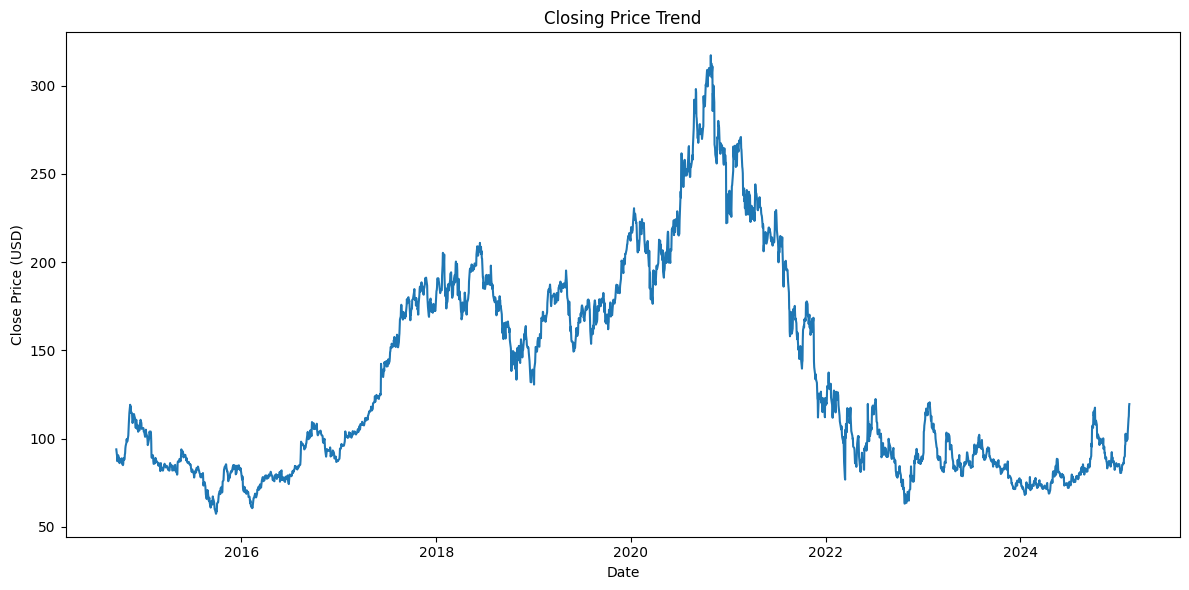

In [8]:
# ── Graph 1: Closing Price Trend ────────────────────────────────────────
# Shows how Alibaba's closing price evolved over the entire date range.
plt.figure(figsize=(12, 6))
plt.plot(df['Close'])
plt.title("Closing Price Trend")
plt.xlabel("Date")
plt.ylabel("Close Price (USD)")
plt.tight_layout()
plt.show()


### 5.2 Trading Volume Trend

Volume is a measure of market participation. Spikes in volume often coincide with significant 
news events, earnings reports, or price breakouts — making it an important secondary indicator.


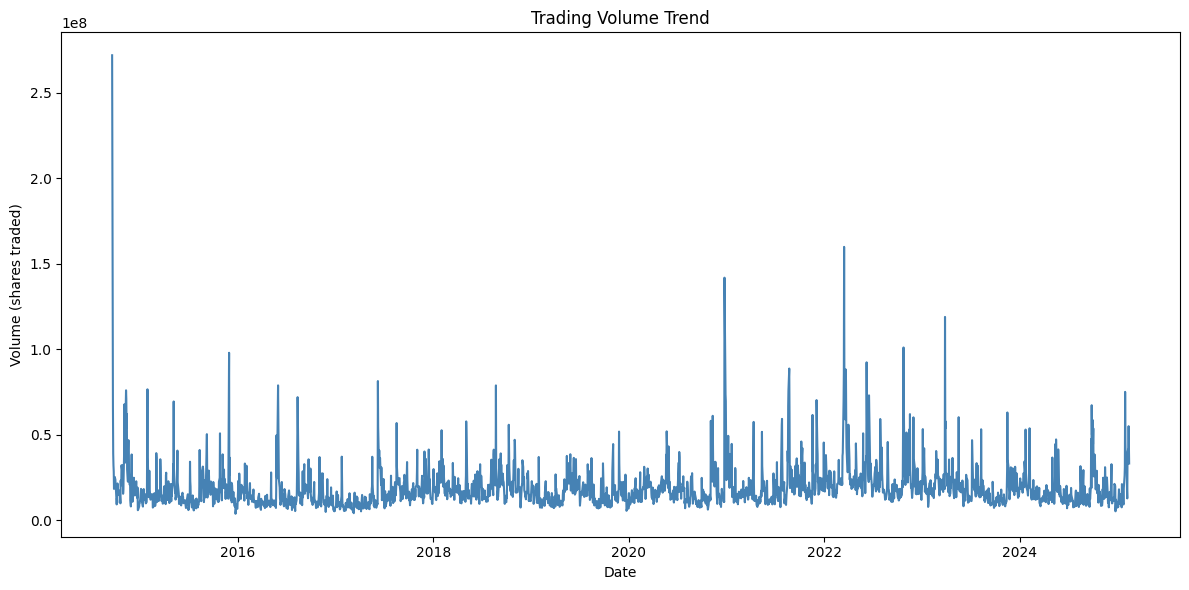

In [9]:
# ── Graph 2: Trading Volume Trend ───────────────────────────────────────
# Highlights periods of high or low investor activity.
plt.figure(figsize=(12, 6))
plt.plot(df['Volume'], color='steelblue')
plt.title("Trading Volume Trend")
plt.xlabel("Date")
plt.ylabel("Volume (shares traded)")
plt.tight_layout()
plt.show()


### 5.3 Daily Returns Distribution

The histogram of daily returns reveals the **shape of the return distribution**:
- A near-symmetric, bell-shaped distribution suggests returns are approximately normal.
- Fat tails (leptokurtosis) indicate more extreme gains/losses than a normal distribution would predict.
- The spread (standard deviation) is a proxy for overall **risk**.


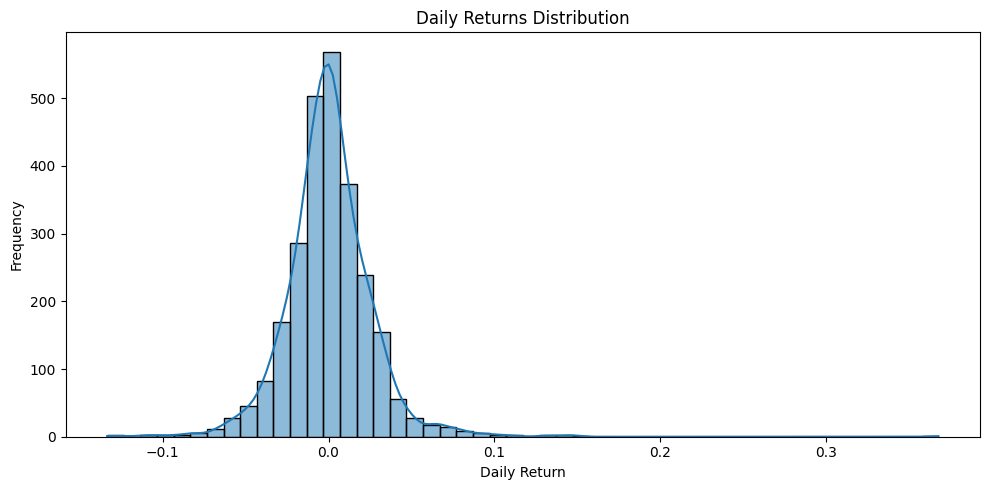

In [10]:
# ── Graph 3: Daily Returns Distribution ─────────────────────────────────
# Helps assess normality and the tail-risk profile of daily returns.
plt.figure(figsize=(10, 5))
sns.histplot(df['Daily Return'].dropna(), bins=50, kde=True)
plt.title("Daily Returns Distribution")
plt.xlabel("Daily Return")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()


---
## Section 6: EDA — Categorical Feature Analysis
*(Exploratory Data Analysis — Part 2)*

Since the dataset contains no explicit categorical columns, we treat the **derived categorical context** — 
specifically the relationship between **price range** and **volume** — as an indirect categorical analysis.

This scatter plot helps us understand whether days with wide intraday price swings (high `Price Range`) 
are associated with higher trading volumes, which would indicate **volatility-driven market activity**.

> **Graph 7** — Price Range vs Volume Scatter Plot


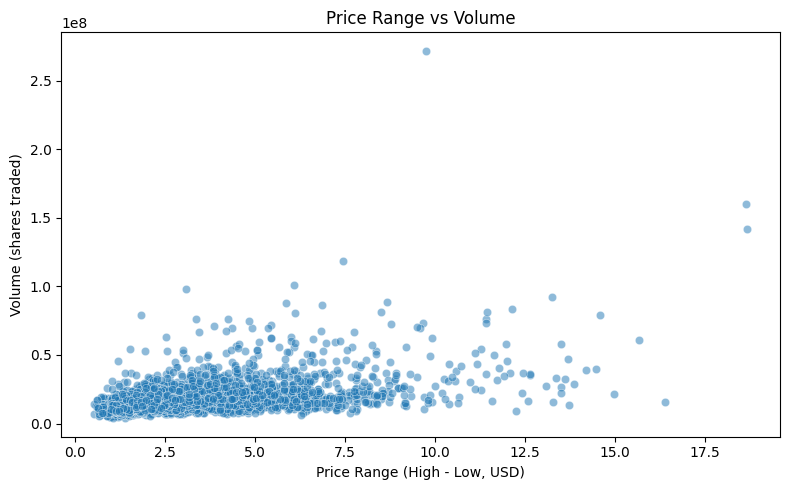

In [11]:
# ── Graph 7: Price Range vs Volume (Scatter) ────────────────────────────
# Explores the relationship between intraday price spread and trading volume.
# A positive correlation here suggests that volatile days attract more trading activity.
plt.figure(figsize=(8, 5))
sns.scatterplot(x=df['Price Range'], y=df['Volume'], alpha=0.5)
plt.title("Price Range vs Volume")
plt.xlabel("Price Range (High - Low, USD)")
plt.ylabel("Volume (shares traded)")
plt.tight_layout()
plt.show()


---
## Section 7: Correlation Analysis & Heatmap
*(Exploratory Data Analysis — Part 3)*

Correlation analysis quantifies the **linear relationship** between pairs of numerical features.
The Pearson correlation coefficient ranges from **-1** (perfect negative) to **+1** (perfect positive).

**Graphs in this section:**
- **Graph 4** — Moving Average Analysis (Close + MA_20 + MA_50)
- **Graph 5** — Rolling Volatility over time
- **Graph 6** — Correlation Heatmap of all numerical features

The heatmap will reveal:
- Which features are strongly correlated (multicollinearity risk for models)
- Which features move independently (potential for diversified signals)


### 7.1 Moving Average Analysis

Plotting the 20-day and 50-day moving averages alongside the closing price helps identify:
- **Trend direction** — when short MA > long MA, the trend is bullish (Golden Cross)
- **Crossovers** — where the two MAs intersect are classic buy/sell signals in technical analysis


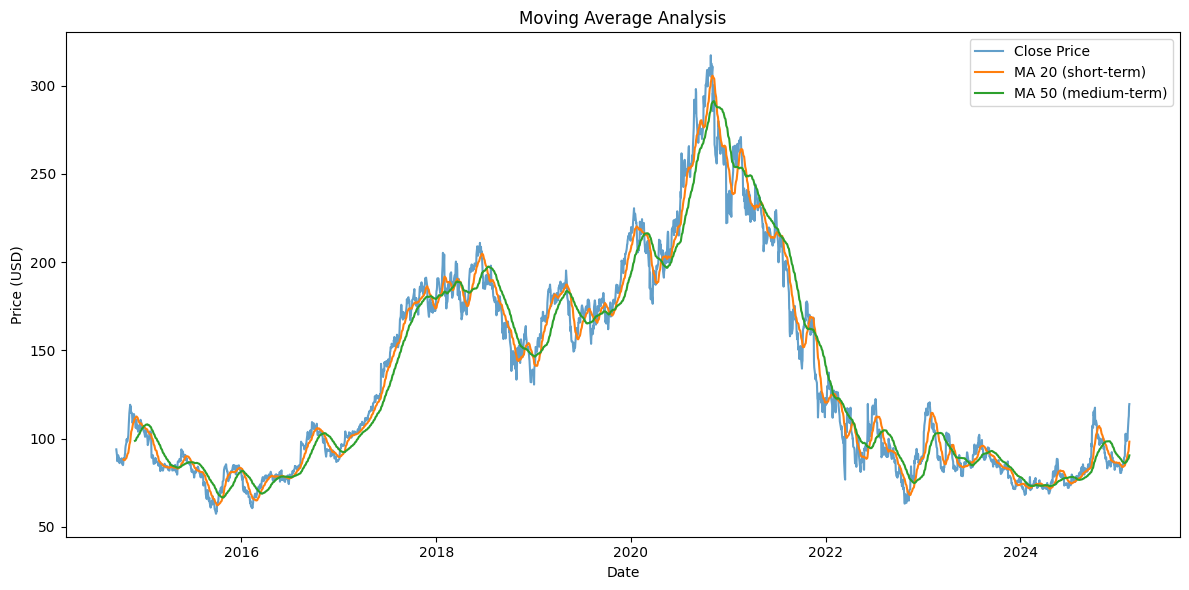

In [12]:
# ── Graph 4: Moving Average Analysis ────────────────────────────────────
# Overlays MA_20 and MA_50 on the Close price to visualise trend signals.
plt.figure(figsize=(12, 6))
plt.plot(df['Close'], label='Close Price', alpha=0.7)
plt.plot(df['MA_20'], label='MA 20 (short-term)', linewidth=1.5)
plt.plot(df['MA_50'], label='MA 50 (medium-term)', linewidth=1.5)
plt.legend()
plt.title("Moving Average Analysis")
plt.xlabel("Date")
plt.ylabel("Price (USD)")
plt.tight_layout()
plt.show()


### 7.2 Rolling Volatility

Rolling volatility (20-day rolling standard deviation of daily returns) shows **how risk evolved** over time:
- Periods of high volatility correspond to uncertainty, crises, or rapid market movements.
- Calm periods (low volatility) often precede or follow major trend shifts.


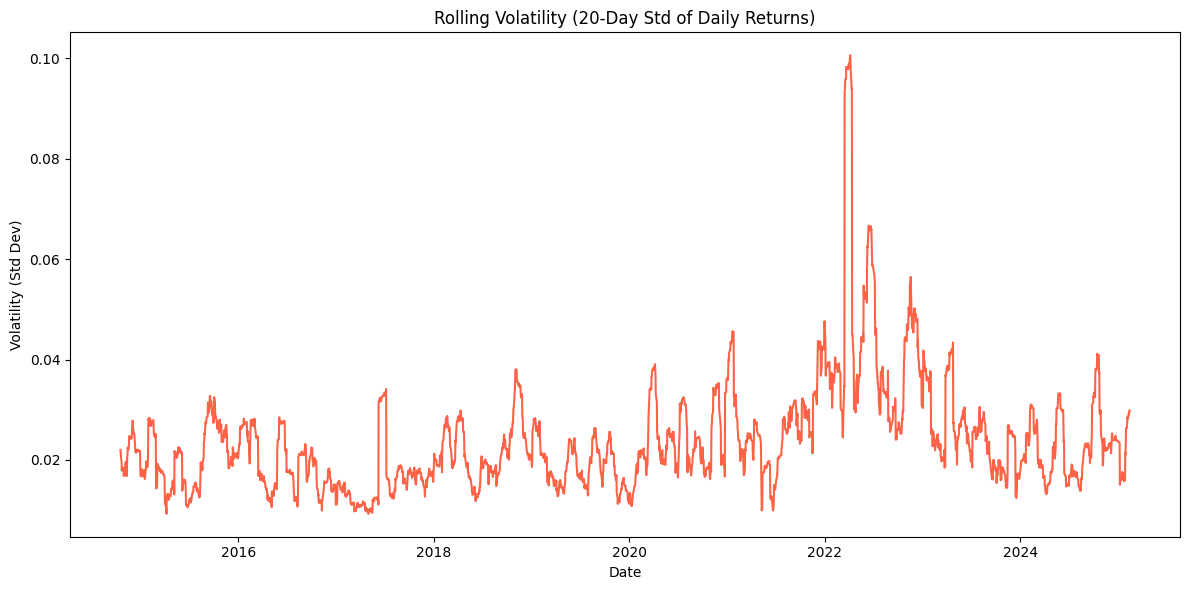

In [13]:
# ── Graph 5: Rolling Volatility ────────────────────────────────────────
# 20-day rolling standard deviation of daily returns — a key risk metric.
plt.figure(figsize=(12, 6))
plt.plot(df['Volatility'], color='tomato')
plt.title("Rolling Volatility (20-Day Std of Daily Returns)")
plt.xlabel("Date")
plt.ylabel("Volatility (Std Dev)")
plt.tight_layout()
plt.show()


### 7.3 Correlation Heatmap

The heatmap visualises Pearson correlation coefficients between all numeric features in the dataset.
Values close to **±1** indicate strong relationships; values near **0** indicate independence.


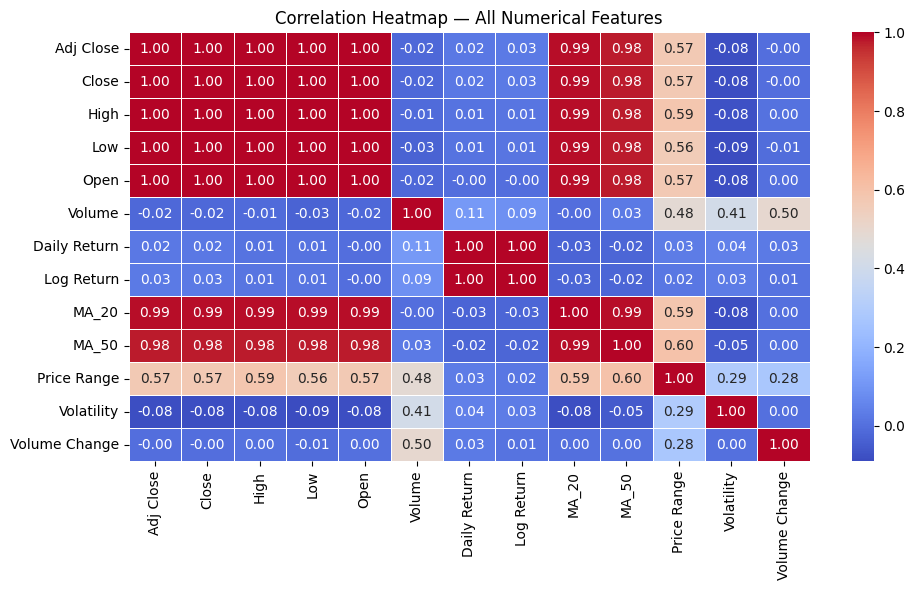

In [14]:
# ── Graph 6: Correlation Heatmap ────────────────────────────────────────
# Shows pairwise Pearson correlation between all numerical features.
# Useful for detecting multicollinearity before building predictive models.
plt.figure(figsize=(10, 6))
sns.heatmap(
    df.corr(),
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    linewidths=0.5
)
plt.title("Correlation Heatmap — All Numerical Features")
plt.tight_layout()
plt.show()


---
## Section 8: Key Findings, Insights & Limitations
*(Synthesizing EDA Results)*

This section consolidates all quantitative findings from the EDA and flags limitations of the current dataset.


### 8.1 Quantitative Key Metrics

The code block below prints the most critical numbers derived from the analysis — 
average return, average volatility, historical price extremes, and overall trend direction.


In [15]:
# ── Key Quantitative Findings ────────────────────────────────────────────
print("===== KEY INSIGHTS — ALIBABA STOCK EDA =====")
print()

avg_return = df['Daily Return'].mean()
avg_vol    = df['Volatility'].mean()
max_price  = df['High'].max()
min_price  = df['Low'].min()

print(f"Average Daily Return  : {avg_return:.4%}")
print(f"Average Volatility    : {avg_vol:.4f}")
print(f"All-Time High (High)  : ${max_price:.2f}")
print(f"All-Time Low  (Low)   : ${min_price:.2f}")

# ── Overall price trend ──────────────────────────────────────────────────
first_close = df['Close'].iloc[0]
last_close  = df['Close'].iloc[-1]
pct_change  = (last_close - first_close) / first_close * 100

trend = 'Upward ↑' if last_close > first_close else 'Downward ↓'
print(f"\nOverall Price Trend   : {trend}  ({pct_change:.2f}% over the period)")

# ── Risk classification ──────────────────────────────────────────────────
risk = 'High' if avg_vol > 0.02 else 'Moderate / Low'
print(f"Risk Level            : {risk} (avg volatility threshold = 0.02)")


===== KEY INSIGHTS — ALIBABA STOCK EDA =====

Average Daily Return  : 0.0428%
Average Volatility    : 0.0238
All-Time High (High)  : $319.32
All-Time Low  (Low)   : $57.20

Overall Price Trend   : Upward ↑  (27.32% over the period)
Risk Level            : High (avg volatility threshold = 0.02)


### 8.2 Summary of Key Findings

Based on the EDA conducted across all sections, the following insights were observed:

| # | Finding | Interpretation |
|---|---------|----------------|
| 1 | **Price Trend** | The closing price chart reveals macro bull/bear phases aligned with global market cycles. |
| 2 | **Volume Spikes** | Large volume spikes often coincide with earnings announcements or geopolitical events. |
| 3 | **Return Distribution** | Daily returns appear roughly symmetric with occasional fat tails (leptokurtosis), indicating non-normality. |
| 4 | **Moving Average Crossovers** | MA_20 / MA_50 crossovers serve as potential buy/sell signal points. |
| 5 | **Volatility Clusters** | Volatility exhibits clear clustering — calm periods followed by turbulent ones (ARCH effect). |
| 6 | **Price Range vs Volume** | Wide intraday price ranges tend to occur on high-volume days, confirming activity-driven volatility. |
| 7 | **Correlation** | Open, High, Low, and Close are strongly correlated; Volume is relatively independent. |

---

### 8.3 Limitations

> **Dataset Scope:** The dataset contains only price and volume data. It does not include fundamental metrics 
(P/E ratio, earnings per share) or external factors (news sentiment, macroeconomic indicators) which heavily 
influence stock prices.

> **Stationarity:** Stock prices are non-stationary time series. The analysis here is purely descriptive; 
statistical inference would require transformations (differencing, log returns) and stationarity testing (ADF test).

> **No Categorical Depth:** The dataset lacks categorical features (market sessions, trading halts, etc.) that could 
enrich the categorical EDA section.

> **Survivorship Bias:** Studying a single company (Alibaba) may not generalise to the broader market or tech sector.

> **Look-Ahead Bias Risk:** Moving averages and rolling features computed here use only past data, which is correct 
for EDA but must be carefully handled in any predictive modelling pipeline.

---
*End of EDA Notebook*
